# Exploratory Data Analysis (EDA)
## Project Title: Machine Learning-Based Risk Prediction Model for Loan Application

**Dataset:** Home Credit Default Risk (`application_train.csv`)  
**Target Variable:** `TARGET`  
- `0` = No default (low risk)  
- `1` = Default (high risk)

**EDA Goals:**
- Understand dataset structure
- Check missing values
- Explore target imbalance
- Analyze numeric & categorical features
- Study relationship of features with TARGET


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
train = pd.read_csv("/content/application_train.csv")

print("Shape:", train.shape)
train.head()


Shape: (9692, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 1. Dataset Structure and Data Types
We check the column names, data types, and general structure of the dataset.


In [ ]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9692 entries, 0 to 9691
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(103), int64(3), object(16)
memory usage: 9.0+ MB


## 2. Statistical Summary
Basic descriptive statistics for numeric variables.


In [ ]:
train.describe().T.head(5)


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,9692.0,105652.346574,3256.587947,100002.0,102827.75,105665.5,108462.25,111275.0
TARGET,9692.0,0.077899,0.268027,0.0,0.00,0.0,0.00,1.0
CNT_CHILDREN,9692.0,0.415600,0.718289,0.0,0.00,0.0,1.00,7.0
AMT_INCOME_TOTAL,9692.0,167626.199762,94666.571321,25650.0,112500.00,144000.0,202500.00,1935000.0
AMT_CREDIT,9692.0,601399.705376,404023.808893,45000.0,270000.00,512392.5,810000.00,2961000.0


## 3. Duplicate Check
We check if there are duplicate rows and duplicate customer IDs.


In [ ]:
print("Duplicate rows:", train.duplicated().sum())
print("Duplicate SK_ID_CURR:", train["SK_ID_CURR"].duplicated().sum())


Duplicate rows: 0
Duplicate SK_ID_CURR: 0


## 4. Target Variable Distribution (Loan Risk)
We analyze how many applicants defaulted vs not defaulted.
This also helps us identify class imbalance.


In [ ]:
train["TARGET"].value_counts()


,count
TARGET,
0,8937
1,755


In [ ]:
default_rate = train["TARGET"].mean()
print("Default Rate:", round(default_rate*100, 2), "%")


Default Rate: 7.79 %


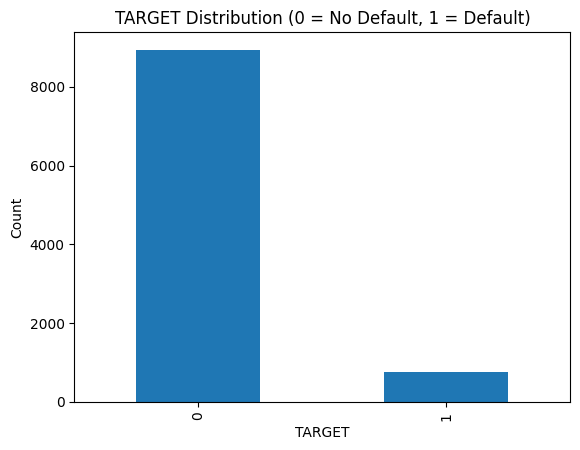

In [ ]:
plt.figure()
train["TARGET"].value_counts().plot(kind="bar")
plt.title("TARGET Distribution (0 = No Default, 1 = Default)")
plt.xlabel("TARGET")
plt.ylabel("Count")
plt.show()


## 5. Missing Values Analysis
We compute missing value percentage for each feature and visualize top missing columns.


In [ ]:
missing_percent = train.isnull().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)

missing_percent.head(5)


,0
COMMONAREA_AVG,69.696657
COMMONAREA_MODE,69.696657
COMMONAREA_MEDI,69.696657
NONLIVINGAPARTMENTS_MEDI,69.335534
NONLIVINGAPARTMENTS_MODE,69.335534


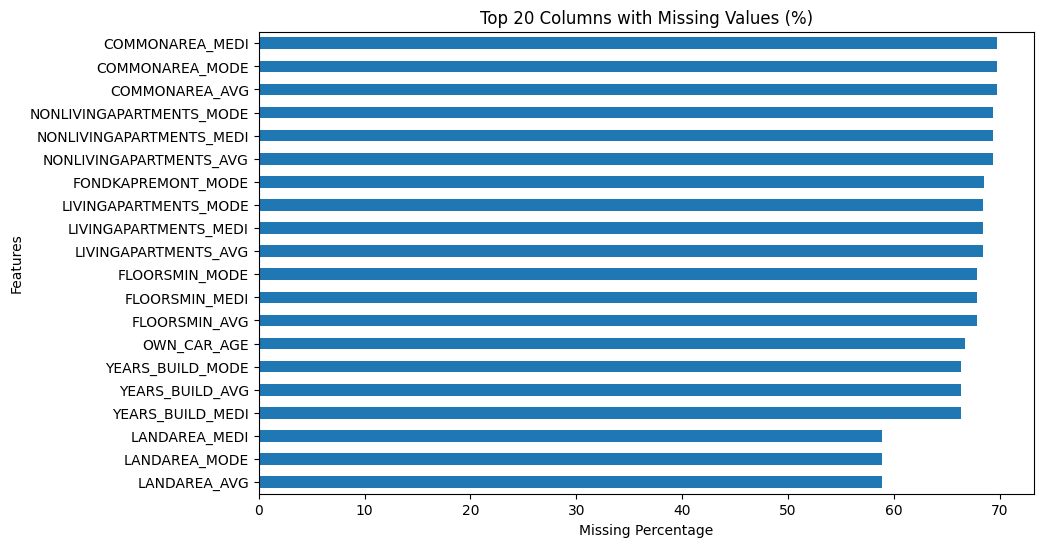

In [ ]:
plt.figure(figsize=(10,6))
missing_percent.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Columns with Missing Values (%)")
plt.xlabel("Missing Percentage")
plt.ylabel("Features")
plt.show()


## 6. Separate Numeric and Categorical Features
We split columns into numeric and categorical to analyze them separately.


In [ ]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))
cat_cols[:10]


Numeric columns: 106
Categorical columns: 16


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE']

## 7. Numeric Feature Distributions
We analyze key numeric variables related to loan risk.


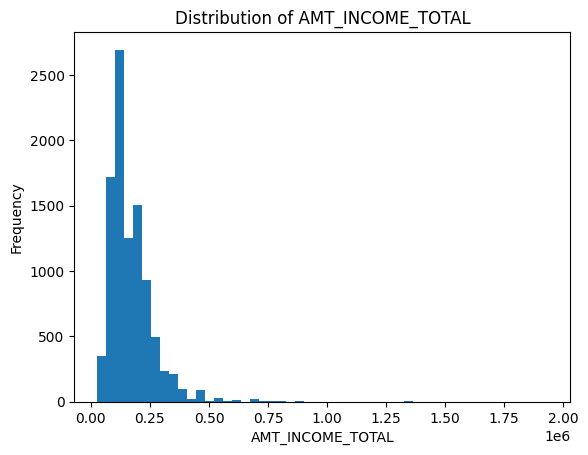

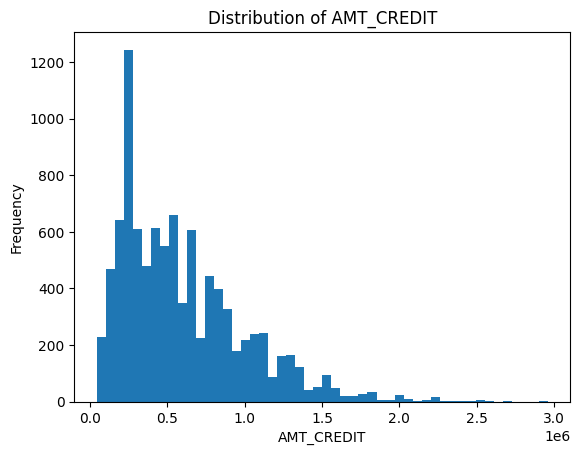

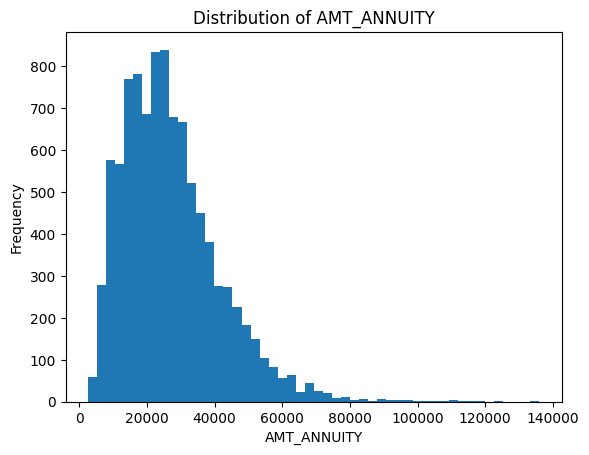

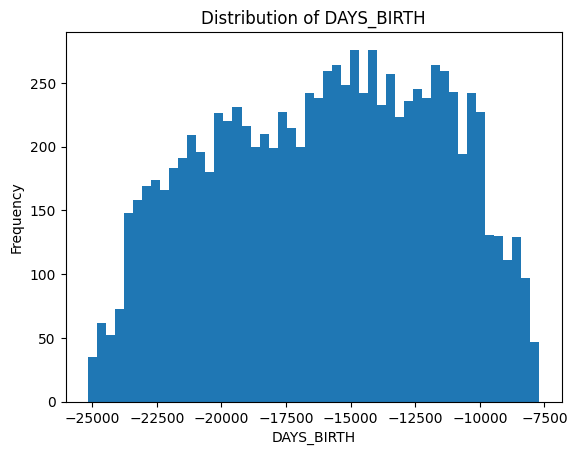

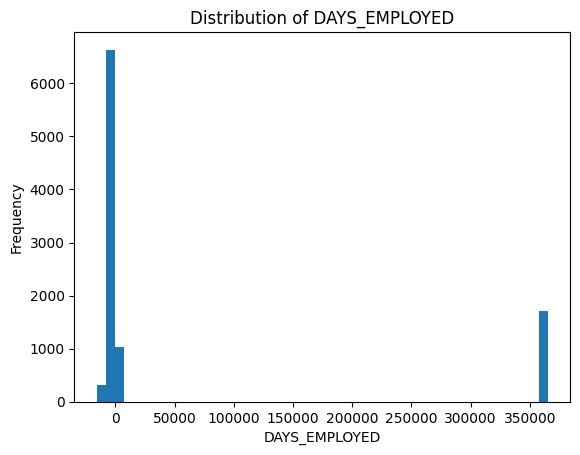

In [ ]:
key_numeric = ["AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","DAYS_BIRTH","DAYS_EMPLOYED"]

for col in key_numeric:
    if col in train.columns:
        plt.figure()
        train[col].replace([np.inf,-np.inf], np.nan).dropna().plot(kind="hist", bins=50)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()


## 8. Categorical Feature Counts
We inspect major categories for important applicant features.


In [ ]:
key_cats = ["CODE_GENDER","NAME_INCOME_TYPE","NAME_EDUCATION_TYPE","NAME_FAMILY_STATUS","NAME_HOUSING_TYPE"]

for col in key_cats:
    if col in train.columns:
        print("\n", col)
        print(train[col].value_counts().head(10))



 CODE_GENDER
CODE_GENDER
F    6406
M    3286
Name: count, dtype: int64

 NAME_INCOME_TYPE
NAME_INCOME_TYPE
Working                 5099
Commercial associate    2240
Pensioner               1717
State servant            634
Unemployed                 2
Name: count, dtype: int64

 NAME_EDUCATION_TYPE
NAME_EDUCATION_TYPE
Secondary / secondary special    6899
Higher education                 2344
Incomplete higher                 308
Lower secondary                   133
Academic degree                     8
Name: count, dtype: int64

 NAME_FAMILY_STATUS
NAME_FAMILY_STATUS
Married                 6265
Single / not married    1405
Civil marriage           912
Separated                595
Widow                    515
Name: count, dtype: int64

 NAME_HOUSING_TYPE
NAME_HOUSING_TYPE
House / apartment      8578
With parents            473
Municipal apartment     367
Rented apartment        156
Office apartment         73
Co-op apartment          45
Name: count, dtype: int64


## 9. Default Rate by Category (Risk Segmentation)
We compute average TARGET (default rate) for different categories.
Higher mean = higher risk.


In [ ]:
def default_rate_by_category(df, col, min_count=500):
    grp = df.groupby(col)["TARGET"].agg(["count","mean"]).sort_values("mean", ascending=False)
    return grp[grp["count"] >= min_count]

for col in ["CODE_GENDER","NAME_INCOME_TYPE","NAME_EDUCATION_TYPE","NAME_FAMILY_STATUS"]:
    if col in train.columns:
        print("\nDefault rate by:", col)
        display(default_rate_by_category(train, col))



Default rate by: CODE_GENDER


,count,mean
CODE_GENDER,,
M,3286,0.098904
F,6406,0.067125



Default rate by: NAME_INCOME_TYPE


,count,mean
NAME_INCOME_TYPE,,
Working,5099,0.092371
Commercial associate,2240,0.068304
Pensioner,1717,0.057076
State servant,634,0.052050



Default rate by: NAME_EDUCATION_TYPE


,count,mean
NAME_EDUCATION_TYPE,,
Secondary / secondary special,6899,0.087839
Higher education,2344,0.043515



Default rate by: NAME_FAMILY_STATUS


,count,mean
NAME_FAMILY_STATUS,,
Civil marriage,912,0.097588
Separated,595,0.090756
Single / not married,1405,0.088968
Married,6265,0.072945
Widow,515,0.058252


## 10. Correlation with TARGET (Numeric Features)
We identify numeric features most correlated with default risk.


In [ ]:
corr = train.corr(numeric_only=True)["TARGET"].sort_values()

print("Top 10 Negative correlations (reduce risk):")
print(corr.head(10))

print("\nTop 10 Positive correlations (increase risk):")
print(corr.tail(11))


Top 10 Negative correlations (reduce risk):
EXT_SOURCE_3                 -0.195988
EXT_SOURCE_2                 -0.170661
EXT_SOURCE_1                 -0.162566
AMT_GOODS_PRICE              -0.050480
AMT_CREDIT                   -0.043201
DAYS_EMPLOYED                -0.034957
FLAG_PHONE                   -0.034243
FLOORSMIN_AVG                -0.032316
FLOORSMIN_MEDI               -0.032307
REGION_POPULATION_RELATIVE   -0.031621
Name: TARGET, dtype: float64

Top 10 Positive correlations (increase risk):
DAYS_LAST_PHONE_CHANGE         0.066693
REGION_RATING_CLIENT           0.069947
REGION_RATING_CLIENT_W_CITY    0.071166
DAYS_ID_PUBLISH                0.072557
DAYS_BIRTH                     0.091807
TARGET                         1.000000
FLAG_MOBIL                          NaN
FLAG_DOCUMENT_2                     NaN
FLAG_DOCUMENT_7                     NaN
FLAG_DOCUMENT_10                    NaN
FLAG_DOCUMENT_12                    NaN
Name: TARGET, dtype: float64


# EDA Summary / Findings

**Key Findings:**
1. TARGET is imbalanced (few defaulters compared to non-defaulters).
2. Many columns contain missing values, some with very high missing percentages.
3. Financial variables (income, credit, annuity) are right-skewed and contain outliers.
4. Applicant demographic categories show different default rates.
5. Correlation analysis highlights important numeric predictors for risk.

**Next Steps:**
- Handle missing values
- Encode categorical variables
- Balance classes (SMOTE/class weights)
- Train models: Logistic Regression, Random Forest, XGBoost


# Initial Model Implementation for Loan Default Prediction

To answer the research questions, three machine learning models are implemented:

1. Logistic Regression
2. Random Forest
3. XGBoost

These models are evaluated using accuracy, precision, recall, F1-score, and ROC-AUC score.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
# Drop ID column if exists
if 'SK_ID_CURR' in train.columns:
    train = train.drop(columns=['SK_ID_CURR'])

# Target column (usually TARGET in loan dataset)
y = train['TARGET']
X = train.drop('TARGET', axis=1)

# Convert categorical to dummy variables
X = pd.get_dummies(X, drop_first=True)

# Fill missing values
X = X.fillna(X.median())

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model 1: Logistic Regression
Logistic Regression is used as a baseline model for binary classification.

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.9298607529654461
ROC-AUC: 0.7154728817597078
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      1799
           1       0.70      0.05      0.09       140

    accuracy                           0.93      1939
   macro avg       0.82      0.52      0.53      1939
weighted avg       0.91      0.93      0.90      1939



## Model 2: Random Forest
Random Forest is an ensemble learning method that improves prediction by combining multiple decision trees.

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.927797833935018
ROC-AUC: 0.6985746049392519
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      1799
           1       0.00      0.00      0.00       140

    accuracy                           0.93      1939
   macro avg       0.46      0.50      0.48      1939
weighted avg       0.86      0.93      0.89      1939



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Model 3: XGBoost
XGBoost is a powerful gradient boosting algorithm that often performs well on structured financial datasets.

In [ ]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:45:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results
Accuracy: 0.924187725631769
ROC-AUC: 0.721650917176209
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      1799
           1       0.29      0.04      0.06       140

    accuracy                           0.92      1939
   macro avg       0.61      0.51      0.51      1939
weighted avg       0.88      0.92      0.90      1939



## Model Comparison Summary
The performance of all three models is compared to determine which algorithm best predicts loan default risk.

ROC - Receiver Operating Characteristic

AUC – Area under curve


In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.929861,0.715473
1,Random Forest,0.927798,0.698575
2,XGBoost,0.924188,0.721651


# SHAP Analysis for XGBoost Model

To enhance model interpretability, SHAP (SHapley Additive exPlanations) is applied
to the XGBoost model.

SHAP helps explain how each feature contributes to loan default prediction
for both global and individual predictions.

## 1. Global Feature Importance (SHAP Summary Plot)

This plot shows which features contribute most to loan default prediction.

## 2. Feature Importance Bar Plot

This plot shows overall feature importance based on average SHAP values.

## 3. Individual Prediction Explanation

This explains why the model predicted a specific applicant as high or low risk.

SHAP Summary Plot


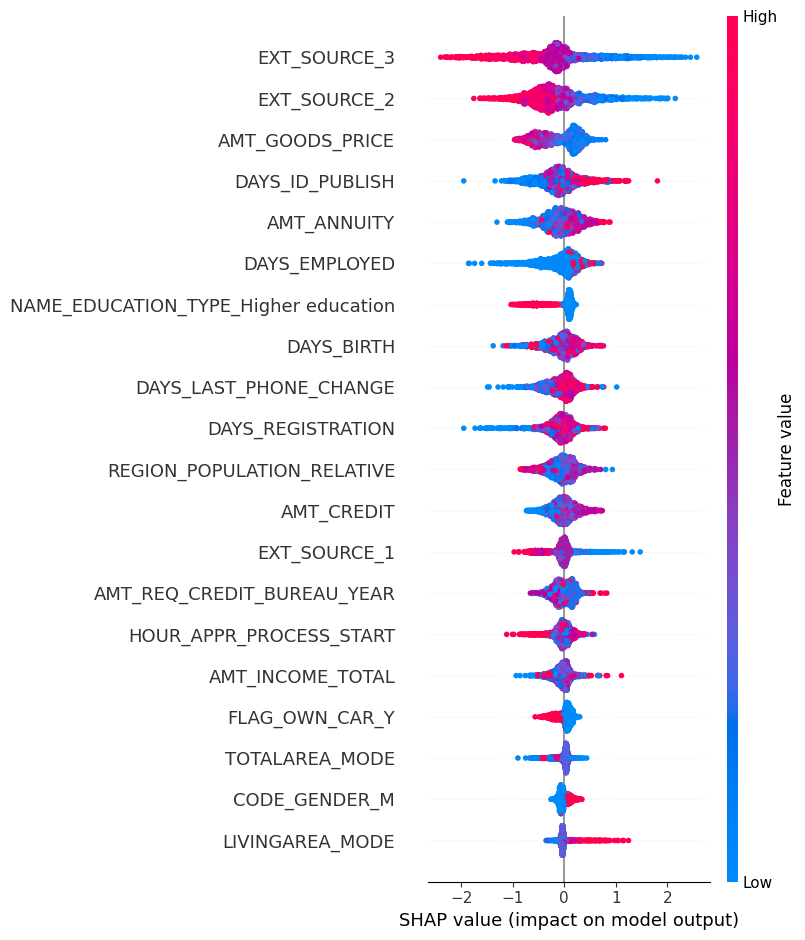

SHAP Feature Importance (Bar Plot)


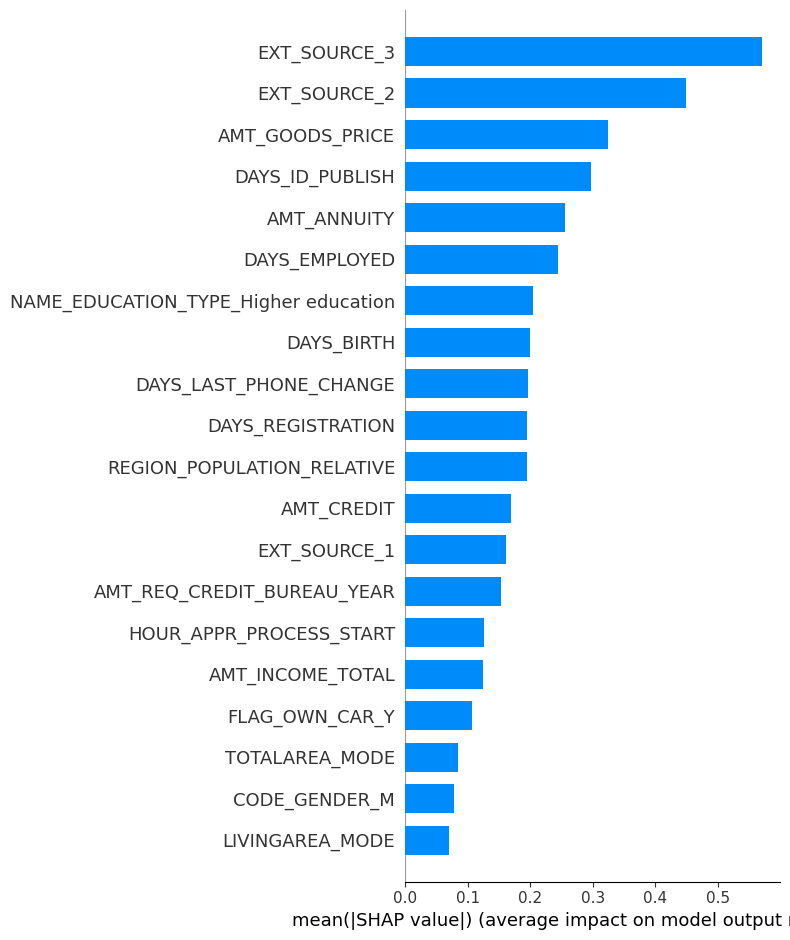

SHAP Force Plot for First Test Sample


In [ ]:
# Install shap if not installed
# !pip install shap

import shap
import matplotlib.pyplot as plt

# Initialize JS visualization
shap.initjs()

# Create SHAP Explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot

print("SHAP Summary Plot")
shap.summary_plot(shap_values, X_test)

#  SHAP Feature Importance (Bar Plot)

print("SHAP Feature Importance (Bar Plot)")
shap.summary_plot(shap_values, X_test, plot_type="bar")

#  Individual Prediction Explanation

print("SHAP Force Plot for First Test Sample")
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

This plot represents XGBoost predict this particular applicant as default / non-default.

Red → pushes prediction towards default (1)

Blue → pushes prediction towards non-default (0)

base value ≈ -2.575

Prediction=BaseValue+∑(SHAPvalues)

In the above graph
Blue features represent financial stability indicators

Red features represent financial risk indicators.

•	SHAP Summary Plot Maximum ≈ +2.0 Minimum ≈ -2.0

•	SHAP Bar Plot Maximum SHAP ≈ +2.0 Minimum SHAP ≈ -1.8

•	SHAP Force Plot for First Test Sample Maximum value ≈ +0.425 Minimum value ≈
 -5.575


The base value represents the average default risk. Red features increase the applicant’s risk, while blue features reduce it. In this case, stable employment and higher education reduced the default probability more than the risk-increasing features, resulting in a low predicted default risk.

## Hyperparameter Tuning using GridSearchCV

After building baseline machine learning models, the next step is **hyperparameter tuning**.
Hyperparameter tuning helps to improve the performance of machine learning models by selecting the best combination of parameters.

In this project, **GridSearchCV** is used to find the optimal parameters for the following models:

* Logistic Regression
* Random Forest
* XGBoost

GridSearchCV works by:

1. Creating multiple combinations of hyperparameters
2. Training the model on each combination
3. Evaluating performance using cross-validation
4. Selecting the best-performing parameter combination

This process helps improve the model's accuracy and generalization ability.


In [ ]:
# Import required libraries

import pandas as pd
import numpy as np

# Model selection
from sklearn.model_selection import GridSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Scaling
from sklearn.preprocessing import StandardScaler

## Preparing Data for Hyperparameter Tuning

Before applying GridSearchCV, the dataset is split into training and testing sets.
Logistic Regression requires **feature scaling**, so StandardScaler is used to normalize the features.

The training dataset will be used by GridSearchCV to perform **cross-validation and parameter tuning**.


In [ ]:
# Scale the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Hyperparameter Tuning for Logistic Regression

For Logistic Regression, the following parameters are tuned:

* **C** → Controls regularization strength
* **penalty** → Type of regularization (L1 or L2)
* **solver** → Algorithm used for optimization

GridSearchCV will test different combinations of these parameters and select the best one based on cross-validation performance.


In [ ]:
# Logistic Regression Model

log_model = LogisticRegression(max_iter=1000)

# Hyperparameter grid

log_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

# GridSearchCV

grid_log = GridSearchCV(
    estimator=log_model,
    param_grid=log_params,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

# Train

grid_log.fit(X_train_scaled, y_train)

# Best model

best_log_model = grid_log.best_estimator_

print("Best Parameters:", grid_log.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}


## Hyperparameter Tuning for Random Forest

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions.

The following parameters are tuned:

* **n_estimators** → Number of trees in the forest
* **max_depth** → Maximum depth of each tree
* **min_samples_split** → Minimum samples required to split a node
* **min_samples_leaf** → Minimum samples required at a leaf node

GridSearchCV evaluates multiple parameter combinations to find the best-performing Random Forest model.


In [ ]:
# Random Forest Model

rf_model = RandomForestClassifier(random_state=42)

# Parameter grid

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearch

grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_params,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

# Train

grid_rf.fit(X_train, y_train)

# Best model

best_rf_model = grid_rf.best_estimator_

print("Best Parameters:", grid_rf.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


## Hyperparameter Tuning for XGBoost

XGBoost is a powerful gradient boosting algorithm widely used for structured data problems.

The following parameters are tuned:

* **n_estimators** → Number of boosting rounds
* **max_depth** → Maximum depth of trees
* **learning_rate** → Step size used during training
* **subsample** → Fraction of samples used for training

GridSearchCV evaluates different parameter combinations to find the best configuration for the XGBoost model.


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# XGBoost Model (fixed)
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss'
)

# Parameter grid
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1]
}

# GridSearch
grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_params,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

# Train
grid_xgb.fit(X_train, y_train)

# Best model
best_xgb_model = grid_xgb.best_estimator_

print("Best Parameters:", grid_xgb.best_params_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


## ROC-AUC Score Comparison Table

To compare the performance of the trained machine learning models, the **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)** score is calculated.

The ROC-AUC score measures how well a classification model can distinguish between the positive and negative classes. A higher ROC-AUC value indicates better model performance.

In this section, the ROC-AUC scores are calculated for the following models:

* Logistic Regression
* Random Forest
* XGBoost

The predicted probabilities from each model are used to compute the ROC-AUC score using the **roc_auc_score()** function from the `sklearn.metrics` library.

A comparison table is then created using **Pandas DataFrame** to display the ROC-AUC scores of all models, making it easier to identify the best-performing model.


In [ ]:
# Import library
from sklearn.metrics import roc_auc_score

# Get prediction probabilities

log_probs = best_log_model.predict_proba(X_test_scaled)[:,1]
rf_probs = best_rf_model.predict_proba(X_test)[:,1]
xgb_probs = best_xgb_model.predict_proba(X_test)[:,1]

# Calculate ROC-AUC scores

log_auc = roc_auc_score(y_test, log_probs)
rf_auc = roc_auc_score(y_test, rf_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)

# Create comparison table

roc_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC Score": [log_auc, rf_auc, xgb_auc]
})

# Display table

roc_table

,Model,ROC-AUC Score
0,Logistic Regression,0.730636
1,Random Forest,0.727877
2,XGBoost,0.753284


## ROC Curve Comparison

The **Receiver Operating Characteristic (ROC) Curve** is used to evaluate the performance of classification models. It illustrates the ability of a model to distinguish between positive and negative classes.

The ROC curve plots:

* **True Positive Rate (TPR)** on the Y-axis
* **False Positive Rate (FPR)** on the X-axis

A model with a curve closer to the **top-left corner** indicates better performance.

The **Area Under the Curve (AUC)** represents the overall performance of the model:

* **AUC = 1.0** → Perfect model
* **AUC = 0.5** → Random guessing
* **Higher AUC values indicate better model performance**

In this project, ROC curves are plotted for the following models:

* Logistic Regression
* Random Forest
* XGBoost

The comparison helps identify which model performs best in distinguishing between the target classes.


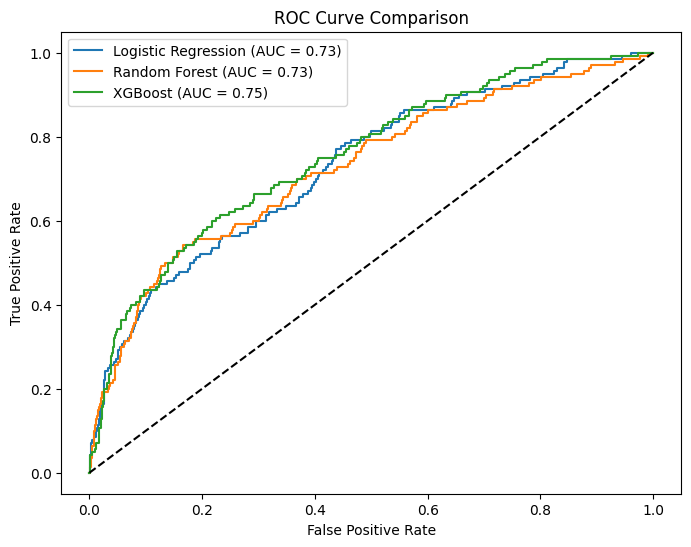

In [ ]:
# Import libraries

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score


# Get prediction probabilities

log_probs = best_log_model.predict_proba(X_test_scaled)[:,1]
rf_probs = best_rf_model.predict_proba(X_test)[:,1]
xgb_probs = best_xgb_model.predict_proba(X_test)[:,1]


# Calculate ROC curve values

log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)


# Calculate AUC scores

log_auc = roc_auc_score(y_test, log_probs)
rf_auc = roc_auc_score(y_test, rf_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)


# Plot ROC Curves

plt.figure(figsize=(8,6))

plt.plot(log_fpr, log_tpr, label=f'Logistic Regression (AUC = {log_auc:.2f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.2f})')

# Random guess line
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

## Final Model Comparison

In this project, three machine learning models were developed and evaluated to predict the target outcome:

* Logistic Regression
* Random Forest
* XGBoost

After completing model training, hyperparameter tuning using **GridSearchCV**, and evaluation using multiple performance metrics, the models were compared using **Accuracy, Precision, Recall, F1-score, and ROC-AUC score**.

### Key Observations

* **Logistic Regression** served as a baseline model and provided stable but relatively lower performance compared to the ensemble models.
* **Random Forest** improved the performance by combining multiple decision trees and capturing non-linear relationships in the data.
* **XGBoost** achieved the best overall performance due to its gradient boosting mechanism, which sequentially improves model predictions.

The **ROC Curve comparison** further confirmed that **XGBoost achieved the highest AUC score**, indicating a better ability to distinguish between positive and negative classes.

### Final Conclusion

Based on the evaluation results, **XGBoost is selected as the best-performing model for this project**. Its ability to handle complex relationships in structured data makes it highly suitable for predictive modeling tasks.

Therefore, the **XGBoost model can be considered the final optimized model for prediction in this study**.
